# PoC: Identificación de idioma, clasificación de intención, extracción de entidades y enrutamiento al FAQ

*Antonio Macías Ferrera · Elsa Domínguez González · Óscar Niño Robles · Nicolás Rodríguez Ruiz*  
*Máster Universitario en Lógica, Computación e Inteligencia Artificial - Universidad de Sevilla*

Este *notebook* implementa la **prueba de concepto (PoC)** del asistente de FAQs de cocina definida en la memoria. El objetivo es demostrar que el *pipeline* `[Idioma -> Intención -> Entidades]` funciona correctamente antes de conectarlo con una base de datos real de FAQs.

**Estructura**

| Sección | Tarea | Contenido |
|---------|-------|----------|
| 1 | T1 Identificación de idioma | lingua: evaluación sobre el conjunto de test |
| 2 | T2 Clasificación de intención | Selección del clasificador (*grid search*), *baseline* trivial, TF-IDF + LinearSVC, métricas por idioma, matrices de confusión, análisis de errores |
| 3 | Reentrenamiento con todos los datos | Entrenamiento del modelo final con el corpus completo y exportación |
| 4 | T3 Extracción de entidades | Vía léxica (diccionarios culinarios) + Vía semántica (`EntityExtractor`, spaCy + similitud coseno), análisis de cobertura |
| 5 | *Pipeline* completo | Función que devuelve `[Idioma, Intención, Entidades]` para cualquier consulta |
| 6 | T4 Propuesta de enrutamiento | Diseño teórico comparativo: Whoosh (léxico) vs. *embeddings* (semántico) |

**Requisito previo**

Ejecutar `Analisis_Datos_PLN.ipynb` para generar los archivos `clean_data_*.csv` en la carpeta `data/`.

## Índice

1. [Identificación de idioma (T1)](#1-Identificación-de-idioma-T1)
2. [Clasificación de intención (T2)](#2-Clasificación-de-intención-T2)
   - [2.1 Selección del clasificador](#21-Selección-del-clasificador)
   - [2.2 Clasificador trivial como *baseline*](#22-Clasificador-trivial-como-*baseline*)
   - [2.3 Modelo TF-IDF + LinearSVC](#23-Modelo-TF-IDF--LinearSVC)
   - [2.4 Comparación de métricas por idioma](#24-Comparación-de-métricas-por-idioma)
   - [2.5 Matrices de confusión](#25-Matrices-de-confusión)
   - [2.6 Análisis de errores](#26-Análisis-de-errores-y-conexión-con-caraterización-lingüistica)
3. [Reentrenamiento con todos los datos](#3-Reentrenamiento-con-todos-los-datos)
4. [Extracción de entidades (T3)](#4-Extracción-de-entidades-T3)
   - [4.1 Vía léxica: diccionarios culinarios](#41-Vía-léxica-diccionarios-culinarios)
   - [4.2 Vía semántica: EntityExtractor (spaCy + similitud coseno)](#42-Vía-semántica-EntityExtractor-spaCy--similitud-coseno)
5. [*Pipeline* completo: \[Idioma, Intención, Entidades\]](#5-Pipeline-completo-Idioma-Intención-Entidades)
   - [5.1 Ejemplos guiados](#51-Ejemplos-guiados)
   - [5.2 Casos difíciles](#52-Casos-difíciles)
6. [Propuestas de enrutamiento al FAQ (T4)](#6-Propuestas-de-enrutamiento-al-FAQ-T4)
   - [6.1 Motor de indexación Whoosh](#61-Motor-de-indexación-Whoosh)
   - [6.2 Vía semántica: *embeddings*](#62-Vía-semántica-embeddings)

In [ ]:
!pip install -q lingua-language-detector spacy pyspellchecker unidecode contractions whoosh
!python -m spacy download es_core_news_md -q
!python -m spacy download en_core_web_md -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 22.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 50.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
warnings.filterwarnings('ignore')

SEED = 42

data_train_en = pd.read_csv('data/clean_data_train_en.csv')
data_test_en  = pd.read_csv('data/clean_data_test_en.csv')
data_train_es = pd.read_csv('data/clean_data_train_es.csv')
data_test_es  = pd.read_csv('data/clean_data_test_es.csv')

INTENT_MAPPING = {
    'meal_suggestion': 1,
    'recipe': 2,
    'ingredients_list': 3,
    'ingredient_substitution': 4,
    'nutrition_info': 5,
    'calories': 6,
    'cook_time': 7,
    'food_last': 8,
}
REV_INTENT = {v: k for k, v in INTENT_MAPPING.items()}

print(f'Train EN: {len(data_train_en)} | Test EN: {len(data_test_en)}')
print(f'Train ES: {len(data_train_es)} | Test ES: {len(data_test_es)}')

Train EN: 960 | Test EN: 240
Train ES: 960 | Test ES: 240


## 1. Identificación de idioma (T1)

Podemos evaluar el rendimiento en la identificación de idioma gracias a que disponemos de los datos etiquetados. Para ello, basta con unificar los conjuntos de prueba de ambos idiomas (aplicando un *shuffle* para aleatorizar el orden), ejecutar el detector lingua sobre este conjunto de test y medir la tasa de acierto.

En teoría, se espera que el modelo acierte casi siempre sobre las muestras de prueba y que, en la práctica (producción), mantenga este mismo rendimiento, salvo en casos excepcionales de bilingüismo extremo.

In [ ]:
!pip install lingua-language-detector -q

In [ ]:
data_language = pd.concat([data_test_en, data_test_es]).sample(frac=1, random_state=SEED)
data_language[:3]

,text,intent,intent_name,language,clean_text
73,how long does it take to cook meal of tuscan,7,cook_time,en,how long cook meal tuscan
174,Déjame saber qué ingredientes necesito para ha...,3,ingredients_list,es,dejame ingrediente necesitar hacer pasta
154,¿Qué se necesita para cocinar lasaña?,3,ingredients_list,es,necesitar cocinar lasana


In [ ]:
from lingua import Language
from utils.preprocesamiento import detector

def predict_language(text):
    lingua_lang = detector.detect_language_of(text)
    return 'es' if lingua_lang == Language.SPANISH else 'en'

data_language['pred'] = data_language['text'].apply(predict_language)

In [ ]:
accuracy = accuracy_score(data_language['language'], data_language['pred'])
print(f"Accuracy total: {accuracy:.1%}")

Accuracy total: 100.0%


El detector de idiomas funciona a la perfección para todo el conjunto de test.

## 2. Clasificación de intención (T2)

### 2.1 Selección del clasificador

Debido al tamaño del conjunto de datos (960 observaciones en cada conjunto de entrenamiento) y tal como se detalla en la Entrega 2, se ha optado por mantener la combinación de TF-IDF y clasificadores clásicos para T2. Se exploran tres arquitecturas sencillas utilizando las implementaciones de scikit-learn: Naive Bayes multinomial, regresión logística y máquinas de soporte vectorial (LinearSVC).

Para no comprometer la honestidad de la evaluación final sobre el conjunto de test, la selección del mejor modelo y la optimización de sus hiperparámetros se realiza mediante validación cruzada estratificada de 5 pliegues.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

def optimize_model(df, language, ngram_range):
    """
    Entrena y optimiza modelos para un idioma y rango de n-gramas dado.
    ngram_range: tupla, ej. (1,1) unigramas, (1,2) uni+bigramas.
    Devuelve el diccionario con los GridSearchCV de cada modelo.
    """
    ngram_label = "UNIGRAMAS (1,1)" if ngram_range == (1, 1) else "UNI+BIGRAMAS (1,2)"
    print(f"\n{'='*60}")
    print(f"INICIANDO: {language.upper()} | MODO: {ngram_label}")
    print(f"{'='*60}\n")

    X = df['clean_text'].fillna('')
    y = df['intent']

    # ── PIPELINES ────────────────────────────────────────────────────────────────
    pipelines = {
        'NaiveBayes': Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=ngram_range)),
            ('clf',  MultinomialNB())
        ]),
        'SVM': Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=ngram_range)),
            ('clf',  LinearSVC(dual=False, max_iter=1000))
        ]),
        'LogReg': Pipeline([
            ('tfidf', TfidfVectorizer(ngram_range=ngram_range)),
            ('clf',  LogisticRegression(max_iter=1000))
        ])
    }

    # ── REJILLA DE HIPERPARÁMETROS ────────────────────────────────────────────────
    param_grids = {
        'NaiveBayes': {'clf__alpha': [0.1, 0.5, 1, 2, 5]},  # Suavizado de Laplace
        'SVM':        {'clf__C':     [0.1, 0.5, 1, 2, 5]},  # Margen del hiperplano separador
        'LogReg':     {'clf__C':     [0.1, 0.5, 1, 2, 5]},  # Inverso de regularización L2
    }

    # ── VALIDACIÓN CRUZADA ────────────────────────────────────────────────────────
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    best_models = {}

    for name, pipeline in pipelines.items():
        print(f"  Buscando hiperparámetros para [{name}]...")
        grid_search = GridSearchCV(pipeline, param_grids[name], cv=cv_strategy, scoring='accuracy', verbose=0)
        grid_search.fit(X, y)
        best_models[name] = grid_search
        print(f"  [{name}] Mejor accuracy: {grid_search.best_score_:.4f} | Params: {grid_search.best_params_}")

    # ── MODELO GANADOR (informativo) ──────────────────────────────────────────────
    best_name = max(best_models, key=lambda k: best_models[k].best_score_)
    print(f"\nGANADOR {language.upper()} ({ngram_label}): {best_name} (accuracy: {best_models[best_name].best_score_:.4f})\n")

    return best_models

In [ ]:
# --- EJECUCION INGLÉS ---
best_models_en_1gram = optimize_model(data_train_en, "Inglés", (1, 1))
best_models_en_2gram = optimize_model(data_train_en, "Inglés", (1, 2))

# --- EJECUCION ESPAÑOL ---
best_models_es_1gram = optimize_model(data_train_es, "Español", (1, 1))
best_models_es_2gram = optimize_model(data_train_es, "Español", (1, 2))


INICIANDO: INGLÉS | MODO: UNIGRAMAS (1,1)

  Buscando hiperparámetros para [NaiveBayes]...
  [NaiveBayes] Mejor accuracy: 0.9344 | Params: {'clf__alpha': 1}
  Buscando hiperparámetros para [SVM]...
  [SVM] Mejor accuracy: 0.9604 | Params: {'clf__C': 0.5}
  Buscando hiperparámetros para [LogReg]...
  [LogReg] Mejor accuracy: 0.9573 | Params: {'clf__C': 2}

GANADOR INGLÉS (UNIGRAMAS (1,1)): SVM (accuracy: 0.9604)


INICIANDO: INGLÉS | MODO: UNI+BIGRAMAS (1,2)

  Buscando hiperparámetros para [NaiveBayes]...
  [NaiveBayes] Mejor accuracy: 0.9437 | Params: {'clf__alpha': 1}
  Buscando hiperparámetros para [SVM]...
  [SVM] Mejor accuracy: 0.9552 | Params: {'clf__C': 2}
  Buscando hiperparámetros para [LogReg]...
  [LogReg] Mejor accuracy: 0.9521 | Params: {'clf__C': 5}

GANADOR INGLÉS (UNI+BIGRAMAS (1,2)): SVM (accuracy: 0.9552)


INICIANDO: ESPAÑOL | MODO: UNIGRAMAS (1,1)

  Buscando hiperparámetros para [NaiveBayes]...
  [NaiveBayes] Mejor accuracy: 0.9385 | Params: {'clf__alpha': 0.5}
 

Los resultados son muy similares para los tres clasificadores, siendo LinearSVC ligeramente superior.

### 2.2 Clasificador trivial como *baseline*

Con **8 clases perfectamente balanceadas**, un clasificador que asigna clases de forma aleatoria y uniforme tiene un rendimiento esperado del **12.5 %** en *accuracy*. Este es el umbral mínimo que debe superar el modelo para justificar su utilidad según los criterios de éxito de la Entrega 2.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy = DummyClassifier(strategy='uniform', random_state=SEED)

# Inglés
dummy.fit(data_train_en['clean_text'], data_train_en['intent'])
y_dummy_en = dummy.predict(data_test_en['clean_text'])
acc_dummy_en = accuracy_score(data_test_en['intent'], y_dummy_en)

# Español
dummy.fit(data_train_es['clean_text'], data_train_es['intent'])
y_dummy_es = dummy.predict(data_test_es['clean_text'])
acc_dummy_es = accuracy_score(data_test_es['intent'], y_dummy_es)

print(f'Accuracy baseline (EN): {acc_dummy_en:.1%}')
print(f'Accuracy baseline (ES): {acc_dummy_es:.1%}')
print(f'Accuracy teórica esperada (1/8 clases): 12.5%')

Accuracy baseline (EN): 12.5%
Accuracy baseline (ES): 12.5%
Accuracy teórica esperada (1/8 clases): 12.5%


### 2.3 Modelo TF-IDF + LinearSVC

Se entrena un modelo independiente por idioma. Esta arquitectura separada es coherente con la hipótesis de diseño de la Entrega 1 (T1 detecta el idioma y enruta a un módulo específico). La representación TF-IDF captura la importancia relativa de los términos discriminativos, y LinearSVC proporciona un clasificador de margen máximo robusto con pocas muestras.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score

def train_evaluate(train_df, test_df, lang_label, C=1):
    vectorizer = TfidfVectorizer()
    model = LinearSVC(C=C, dual=False, max_iter=1000, random_state=SEED)

    X_train = vectorizer.fit_transform(train_df['clean_text'])
    y_train = train_df['intent']
    model.fit(X_train, y_train)

    X_test = vectorizer.transform(test_df['clean_text'])
    y_test = test_df['intent']
    y_pred = model.predict(X_test)

    classes = sorted(y_test.unique())
    names = [REV_INTENT[c] for c in classes]

    print(f'\n=== Resultados [{lang_label}] ===')
    print(classification_report(y_test, y_pred, labels=classes, target_names=names))
    return vectorizer, model, y_test, y_pred

best_C_en = best_models_en_1gram['SVM'].best_params_['clf__C']
best_C_es = best_models_es_1gram['SVM'].best_params_['clf__C']
print(f'Usando C={best_C_en} para EN y C={best_C_es} para ES (de grid search)')

vectorizer_en, model_en, y_test_en, y_pred_en = train_evaluate(
    data_train_en, data_test_en, 'EN', C=best_C_en)
vectorizer_es, model_es, y_test_es, y_pred_es = train_evaluate(
    data_train_es, data_test_es, 'ES', C=best_C_es)

Usando C=0.5 para EN y C=0.5 para ES (de grid search)

=== Resultados [EN] ===
                         precision    recall  f1-score   support

        meal_suggestion       0.93      0.90      0.92        30
                 recipe       0.80      0.80      0.80        30
       ingredients_list       0.93      0.83      0.88        30
ingredient_substitution       1.00      0.97      0.98        30
         nutrition_info       0.97      1.00      0.98        30
               calories       1.00      0.97      0.98        30
              cook_time       0.81      0.97      0.88        30
              food_last       1.00      0.97      0.98        30

               accuracy                           0.93       240
              macro avg       0.93      0.93      0.93       240
           weighted avg       0.93      0.93      0.93       240


=== Resultados [ES] ===
                         precision    recall  f1-score   support

        meal_suggestion       0.93      0.90   

### 2.4 Comparación de métricas por idioma

                         Modelo Accuracy EN F1 macro EN Accuracy ES F1 macro ES
Clasificador trivial (baseline)       12.5%                   12.5%            
             TF-IDF + LinearSVC       92.5%       0.925       94.2%       0.942



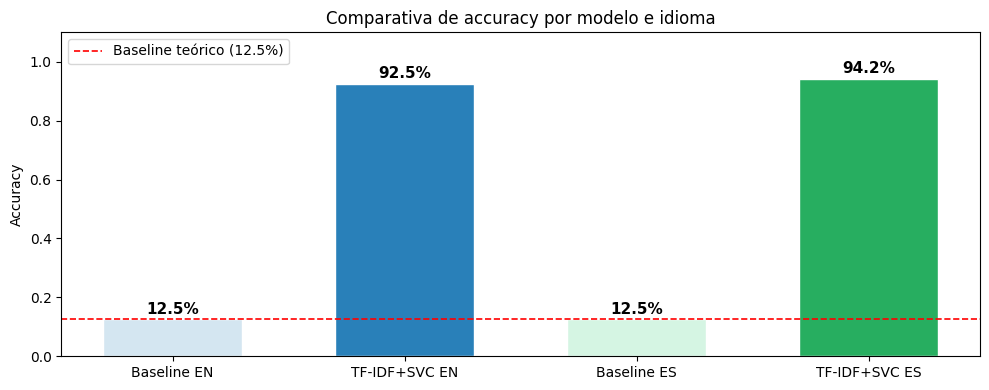

In [ ]:
acc_en = accuracy_score(y_test_en, y_pred_en)
acc_es = accuracy_score(y_test_es, y_pred_es)
f1_en  = f1_score(y_test_en, y_pred_en, average='macro')
f1_es  = f1_score(y_test_es, y_pred_es, average='macro')

df_metrics = pd.DataFrame([
    {'Modelo': 'Clasificador trivial (baseline)',
     'Accuracy EN': f'{acc_dummy_en:.1%}', 'F1 macro EN': '',
     'Accuracy ES': f'{acc_dummy_es:.1%}', 'F1 macro ES': ''},
    {'Modelo': 'TF-IDF + LinearSVC',
     'Accuracy EN': f'{acc_en:.1%}', 'F1 macro EN': f'{f1_en:.3f}',
     'Accuracy ES': f'{acc_es:.1%}', 'F1 macro ES': f'{f1_es:.3f}'},
])
print(df_metrics.to_string(index=False))
print()

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 4))
categorias = ['Baseline EN', 'TF-IDF+SVC EN', 'Baseline ES', 'TF-IDF+SVC ES']
values = [acc_dummy_en, acc_en, acc_dummy_es, acc_es]
colors = ['#d4e6f1', '#2980b9', '#d5f5e3', '#27ae60']
bars = ax.bar(categorias, values, color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(0.125, color='red', linestyle='--', linewidth=1.2, label='Baseline teórico (12.5%)')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy')
ax.set_title('Comparativa de accuracy por modelo e idioma')
ax.legend()
plt.tight_layout()
plt.show()

### 2.5 Matrices de confusión

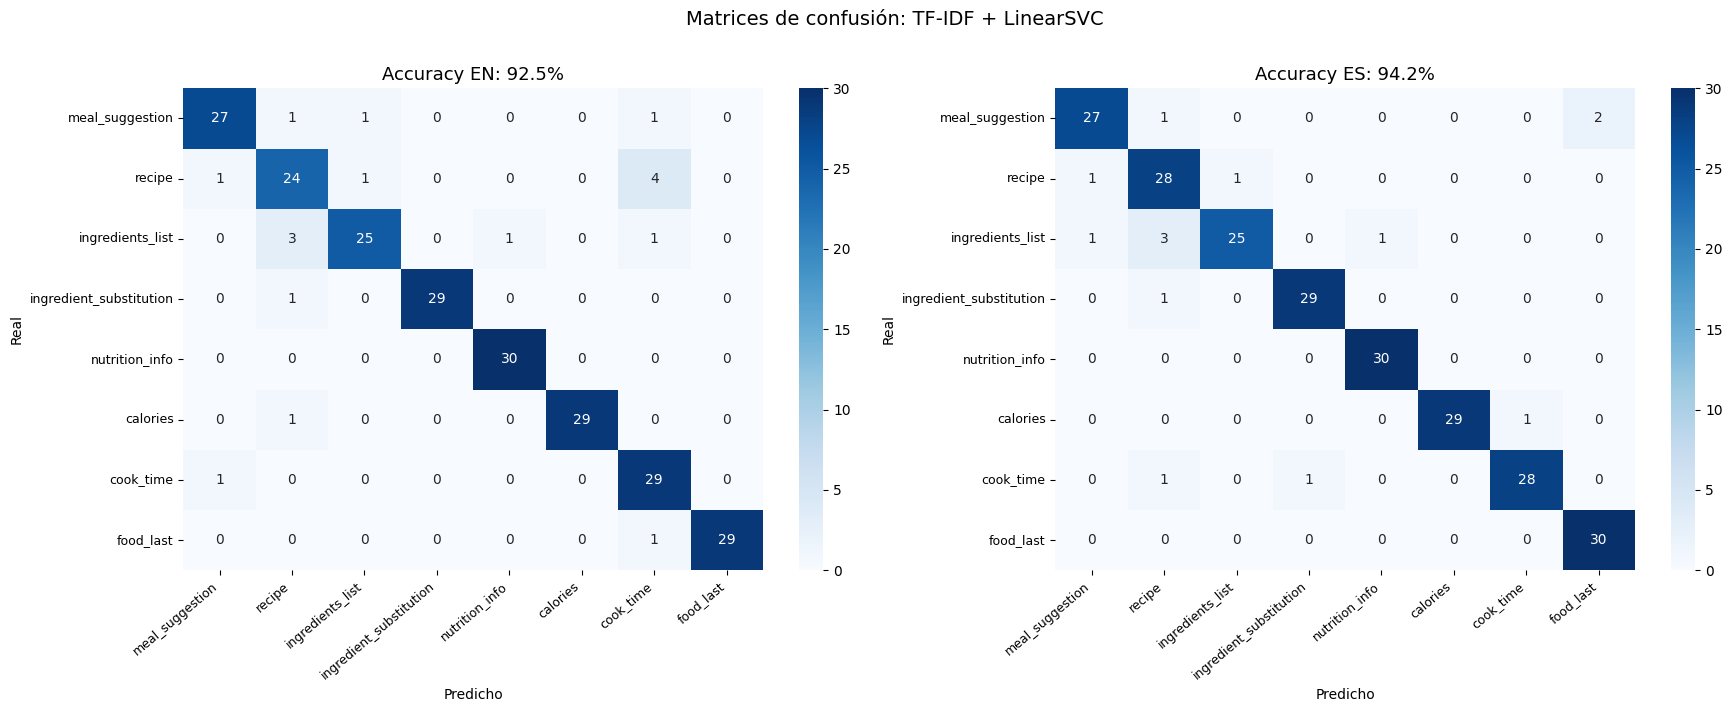

In [ ]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
intent_labels = [REV_INTENT[i] for i in sorted(y_test_en.unique())]

for ax, (y_true, y_pred, titulo) in zip(axes, [
    (y_test_en, y_pred_en, f'Accuracy EN: {acc_en:.1%}'),
    (y_test_es, y_pred_es, f'Accuracy ES: {acc_es:.1%}'),
]):
    cm = confusion_matrix(y_true, y_pred, labels=sorted(y_true.unique()))
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax, cmap='Blues',
        xticklabels=intent_labels, yticklabels=intent_labels
    )
    ax.set_title(titulo, fontsize=13)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', fontsize=9)
    plt.setp(ax.get_yticklabels(), fontsize=9)

plt.suptitle('Matrices de confusión: TF-IDF + LinearSVC', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.6 Análisis de errores y conexión con caraterización lingüistica

Esta sección conecta los fallos de clasificación con las dificultades lingüísticas identificadas en la **Entrega 1**, verificando empíricamente qué fenómenos predichos resultan problemáticos para el modelo.

In [ ]:
def analyze_all_errors(test_df, y_pred, lang_label):
    df_err = test_df.copy().reset_index(drop=True)
    df_err['y_pred']    = y_pred
    df_err['correcto']  = df_err['intent'] == df_err['y_pred']
    df_err['pred_name'] = df_err['y_pred'].map(REV_INTENT)

    errors = df_err[~df_err['correcto']].copy()
    total  = len(test_df)

    print(f'\n{"="*70}')
    print(f'ANÁLISIS DE ERRORES [{lang_label}]: {len(errors)} errores de {total} ({len(errors)/total:.1%})')
    print('='*70)

    # Todos los pares de confusión
    pares = (errors
             .groupby(['intent_name', 'pred_name'])
             .size().reset_index(name='count')
             .sort_values('count', ascending=False))

    print(f'\nTodos los pares de confusión:')
    print(pares.to_string(index=False))

    print(f'\nTodos los ejemplos por par:')
    for _, par in pares.iterrows():
        mask = ((errors['intent_name'] == par['intent_name']) &
                (errors['pred_name']   == par['pred_name']))

        # Obtener todos los ejemplos
        examples = errors[mask]

        print(f"\n  Real: '{par['intent_name']}'  Predicho: '{par['pred_name']}' (n={par['count']})")
        for _, ej in examples.iterrows():
            print(f"    Texto:   {ej['text']}")
            print(f"    Limpio:  {ej['clean_text']}")

    return errors

errors_en = analyze_all_errors(data_test_en, y_pred_en, 'EN')
errors_es = analyze_all_errors(data_test_es, y_pred_es, 'ES')


ANÁLISIS DE ERRORES [EN]: 18 errores de 240 (7.5%)

Todos los pares de confusión:
            intent_name        pred_name  count
                 recipe        cook_time      4
       ingredients_list           recipe      3
              food_last        cook_time      1
              cook_time  meal_suggestion      1
               calories           recipe      1
       ingredients_list        cook_time      1
ingredient_substitution           recipe      1
        meal_suggestion        cook_time      1
       ingredients_list   nutrition_info      1
        meal_suggestion ingredients_list      1
        meal_suggestion           recipe      1
                 recipe ingredients_list      1
                 recipe  meal_suggestion      1

Todos los ejemplos por par:

  Real: 'recipe'  Predicho: 'cook_time' (n=4)
    Texto:   what do i need to do to cook a chicken
    Limpio:  need cook chicken
    Texto:   how do i go about cooking a 10lb turkey
    Limpio:  how cook 10 lb turke

Los errores observados muestran las dificultades identificadas en la caracterización lingüística.

| Fenómeno | Ejemplo de fallo observado | Ejemplo del dataset |
|---------------------|---------------------------|---------------------------|
| **Ambigüedad semántica** | *"is it healthy to eat pizza"* (nutrición, no calorías) | `nutrition_info` <-> `calories` |
| **Petición implícita / pragmática** | *"how healthy is X"* puede pedir info nutricional o calorías | `nutrition_info` <-> `calories` |
| **Solapamiento léxico entre clases** | *recipe* y *ingredients_list* comparten *tokens* como `make`, `how` | `recipe` <-> `ingredients_list` |

Las confusiones entre `nutrition_info` y `calories` son coherentes con el diagnóstico de **ambigüedad pragmática**: tanto *"how healthy is X"* como *"how many calories in X"* buscan información sobre salud/nutrición, pero el modelo debe inferir el nivel de detalle que espera el usuario.

La confusión `recipe` <-> `ingredients_list` refleja el solapamiento léxico señalado en el análisis: ambas intenciones incluyen verbos como `make` o `prepare` y sustantivos de alimentos, lo que hace difícil distinguirlas sin capturar que `ingredients_list` siempre contiene una consulta por *qué lleva* un plato, mientras que `recipe` pregunta por *cómo hacerlo*. Un modelo TF-IDF sin información sintáctica pierde esta distinción.

## 3. Reentrenamiento con todos los datos

Como se menciona en `Analisis_Datos_PLN.ipynb`, no hay suficientes datos de entrenamiento; de hecho, se observaba que existen palabras en Test que no aparecen en el vocabulario de Train.

Simulando lo que se haría en un sistema de producción y para compensar esta falta de datos, vamos a entrenar el mejor modelo obtenido previamente utilizando la totalidad de los datos.


In [ ]:
data_en = pd.concat([data_train_en, data_test_en])
data_es = pd.concat([data_train_es, data_test_es])

print(f'Train EN: {len(data_train_en)} | Test EN: {len(data_test_en)} | EN: {len(data_en)}')
print(f'Train ES: {len(data_train_es)} | Test ES: {len(data_test_es)} | ES: {len(data_es)}')

Train EN: 960 | Test EN: 240 | EN: 1200
Train ES: 960 | Test ES: 240 | ES: 1200


Utilizando la función `train_evaluate` entrenamos el modelo. Cabe resaltar que, aunque se imprimen distintas métricas de evaluación, estas no son significativas al calcularse sobre el mismo conjunto con el que se entrena. Aun así, se mantienen como una prueba de sanidad para asegurarnos de que el modelo está aprendiendo correctamente.

In [ ]:
vectorizer_en, model_en, y_test_en, y_pred_en = train_evaluate(data_en, data_en, 'EN', C=best_C_en)
vectorizer_es, model_es, y_test_es, y_pred_es = train_evaluate(data_es, data_es, 'ES', C=best_C_es)


=== Resultados [EN] ===
                         precision    recall  f1-score   support

        meal_suggestion       1.00      0.99      1.00       150
                 recipe       0.99      0.99      0.99       150
       ingredients_list       0.99      0.99      0.99       150
ingredient_substitution       1.00      1.00      1.00       150
         nutrition_info       1.00      0.99      1.00       150
               calories       0.99      1.00      1.00       150
              cook_time       0.99      1.00      1.00       150
              food_last       1.00      0.99      1.00       150

               accuracy                           0.99      1200
              macro avg       1.00      0.99      1.00      1200
           weighted avg       1.00      0.99      1.00      1200


=== Resultados [ES] ===
                         precision    recall  f1-score   support

        meal_suggestion       1.00      0.99      0.99       150
                 recipe       0.97  

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(vectorizer_en, f"models/vectorizer_en.pkl")
joblib.dump(vectorizer_es, f"models/vectorizer_es.pkl")

joblib.dump(model_en, f"models/model_en.pkl")
joblib.dump(model_es, f"models/model_es.pkl")

print("Modelos guardados en models/")

Modelos guardados en models/


## 4. Extracción de entidades (T3)

T3 contextualiza la intención detectada identificando los conceptos clave de la consulta. Se exploran dos estrategias complementarias.

| Apartado | Estrategia | Herramienta |
|----------|------------|-------------|
| 4.1 | **Vía léxica**: coincidencia exacta de *tokens* normalizados con diccionarios culinarios | `ENTIDADES` dict |
| 4.2 | **Vía semántica**: similitud coseno entre *word embeddings* y vectores ancla por categoría | `EntityExtractor` (spaCy) |


### 4.1 Vía léxica: diccionarios culinarios

Vocabulario controlado con siete categorías semánticas. La detección se basa en intersección exacta de *tokens* normalizados.

In [ ]:
from utils.entidades import ENTITIES, extract_entities

print('Diccionarios culinarios cargados.')
for cat, dic in ENTITIES.items():
    print(f'  {cat}: {len(dic["es"])} términos ES | {len(dic["en"])} términos EN')

Diccionarios culinarios cargados.
  ingredientes: 79 términos ES | 79 términos EN
  tecnicas: 36 términos ES | 36 términos EN
  utensilios: 27 términos ES | 27 términos EN
  dietas: 15 términos ES | 15 términos EN
  paises: 18 términos ES | 18 términos EN
  gentilicios: 18 términos ES | 18 términos EN
  platos_completos: 38 términos ES | 38 términos EN


Aunque internamente esta tarea se realiza utilizando los *inputs* ya procesados (*clean_text*), mostramos algunos ejemplos con la frase completa para mayor comodidad y entendimiento del lector.

In [ ]:
# Demostración de extracción de entidades (vía léxica)
entity_examples = [
    ('como freir pollo en sarten con ajo', 'es'),
    ('quiero hornear pasta con queso y tomate en molde', 'es'),
    ('how long to bake salmon in the oven', 'en'),
    ('can i substitute butter with olive oil in a cake recipe', 'en'),
    ('cuanto tiempo tarda en hervir el arroz en olla', 'es'),
    ('give me ingredients for garlic chicken', 'en'),
    ('querer comida frances casera', 'es')
]

print('EXTRACCIÓN DE ENTIDADES (T3)\n' + '='*60)
for text, lang in entity_examples:
    entities = extract_entities(text, lang)
    print(f'\n[{lang.upper()}] {text}')
    if entities:
        for cat, vals in entities.items():
            print(f'  {cat:15s}: {vals}')
    else:
        print('  (sin entidades detectadas)')

EXTRACCIÓN DE ENTIDADES (T3)

[ES] como freir pollo en sarten con ajo
  ingredientes   : ['ajo', 'pollo']
  tecnicas       : ['freir']
  utensilios     : ['sarten']

[ES] quiero hornear pasta con queso y tomate en molde
  ingredientes   : ['pasta', 'queso', 'tomate']
  tecnicas       : ['hornear']
  utensilios     : ['molde']

[EN] how long to bake salmon in the oven
  ingredientes   : ['salmon']
  tecnicas       : ['bake']
  utensilios     : ['oven']

[EN] can i substitute butter with olive oil in a cake recipe
  ingredientes   : ['butter', 'oil']

[ES] cuanto tiempo tarda en hervir el arroz en olla
  ingredientes   : ['arroz']
  tecnicas       : ['hervir']
  utensilios     : ['olla']

[EN] give me ingredients for garlic chicken
  ingredientes   : ['chicken', 'garlic']

[ES] querer comida frances casera
  gentilicios    : ['frances']


Se observa que, aunque el sistema funciona medianamente bien, falla en algunos casos. Es posible seguir añadiendo palabras al diccionario *ad infinitum*, pero no es una opción razonable.

En el siguiente ejemplo, queríamos que nos devolviera "casera".

```
[ES] querer comida frances casera
  gentilicios    : ['frances']
```



#### Evaluación de la cobertura

A continuación, se calcula qué porcentaje de consultas de test tiene al menos una entidad reconocida por el diccionario.

In [ ]:
# Cobertura
for lang_label, test_df, lang_code in [
    ('EN', data_test_en, 'en'),
    ('ES', data_test_es, 'es'),
]:
    test_df['entities'] = test_df['clean_text'].apply(
        lambda x: extract_entities(str(x), lang_code))
    test_df['n_entities'] = test_df['entities'].apply(
        lambda d: sum(len(v) for v in d.values()))
    coverage = (test_df['n_entities'] > 0).mean()

    print(f'[{lang_label}] Cobertura de entidades en test: {coverage:.1%}')
    print(f'  Media de entidades por consulta: {test_df["n_entities"].mean():.2f}')
    print(f'  Consultas sin entidades: {(test_df["n_entities"] == 0).sum()}')
    print()

    # Cobertura por intención
    print(f'Cobertura por intención [{lang_label}]:')
    intent_coverage = test_df.groupby('intent_name')['n_entities'].agg(
        media='mean', with_entities=lambda x: (x > 0).sum(), total='count')
    intent_coverage['%_coverage'] = (intent_coverage['with_entities'] / intent_coverage['total'] * 100).round(1)
    print(intent_coverage.sort_values('media', ascending=False).to_string())
    print('\n')

[EN] Cobertura de entidades en test: 65.0%
  Media de entidades por consulta: 0.77
  Consultas sin entidades: 84

Cobertura por intención [EN]:
                            media  with_entities  total  %_coverage
intent_name                                                        
ingredient_substitution  1.266667             26     30        86.7
cook_time                0.800000             20     30        66.7
food_last                0.800000             23     30        76.7
meal_suggestion          0.766667             22     30        73.3
calories                 0.666667             15     30        50.0
nutrition_info           0.666667             17     30        56.7
recipe                   0.633333             16     30        53.3
ingredients_list         0.566667             17     30        56.7


[ES] Cobertura de entidades en test: 57.9%
  Media de entidades por consulta: 0.67
  Consultas sin entidades: 101

Cobertura por intención [ES]:
                            m

### 4.2 Vía semántica: `EntityExtractor` (spaCy + similitud coseno)

Alternativa que no depende de un vocabulario cerrado: clasifica cada *token* por similitud coseno con vectores ancla representativos de cada categoría. Permite detectar palabras fuera del diccionario y manejar negaciones y sustituciones mediante análisis sintáctico.

In [ ]:
from utils.entidades import EntityExtractor

In [ ]:
extractor = EntityExtractor()  # Carga es_core_news_md + en_core_web_md
extractor.add_vectors()        # Añade los vectores ancla por defecto

# Consulta básica
text_es = "quiero hacer comida italiana para cenar que me recomiendas"
extractor.pretty_print(*extractor.extract(text_es), text_es)

# Con negación explícita
text_neg = "quiero hacer comida italiana para cenar que me recomiendas sin queso"
extractor.pretty_print(*extractor.extract(text_neg, neg=True), text_neg)

# Comparativa sobre los mismos ejemplos del apartado léxico
print('\nCOMPARATIVA - Vía semántica sobre los mismos ejemplos\n' + '='*60)
for text, lang in entity_examples:
    extractor.pretty_print(*extractor.extract(text, lang=lang), text=text, lang=lang, print_all=False)


[ES] quiero hacer comida italiana para cenar que me recomiendas
  comida_base      : ['comida', 'cenar']
  origen_cultura   : ['italiano']
  tipo_dieta       : []
  ingrediente      : []
  utensilio        : []
  electrodomestico : []
  Entidades: ['comida', 'cenar', 'italiano']

[ES] quiero hacer comida italiana para cenar que me recomiendas sin queso
  comida_base      : ['comida', 'cenar']
  origen_cultura   : ['italiano']
  tipo_dieta       : []
  ingrediente      : ['NO_queso']
  utensilio        : []
  electrodomestico : []
  Entidades: ['comida', 'cenar', 'italiano', 'NO_queso']

COMPARATIVA - Vía semántica sobre los mismos ejemplos

[ES] como freir pollo en sarten con ajo
  Entidades: ['pollo', 'ajo', 'freir', 'sarten']

[ES] quiero hornear pasta con queso y tomate en molde
  Entidades: ['pasta', 'queso', 'tomate', 'hornear', 'molde']

[EN] how long to bake salmon in the oven
  Entidades: ['bake', 'salmon', 'oven']

[EN] can i substitute butter with olive oil in a cake recipe


#### Evaluación de la cobertura

In [ ]:
# Cobertura
for lang_label, test_df, lang_code in [
    ('EN', data_test_en, 'en'),
    ('ES', data_test_es, 'es'),
]:
    # Extracción y conteo de entidades
    test_df['entities'] = test_df['clean_text'].apply(
        lambda x: extractor.extract(str(x), lang=lang_code)[0])
    test_df['n_entities'] = test_df['entities'].apply(len)

    # Estadísticas
    coverage = (test_df['n_entities'] > 0).mean()
    no_entities = test_df[test_df['n_entities'] == 0]

    print(f'[{lang_label}] Cobertura de entidades en test: {coverage:.1%}')
    print(f'  Media de entidades por consulta: {test_df["n_entities"].mean():.2f}')
    print(f'  Consultas sin entidades: {len(no_entities)}')

    if len(no_entities) > 0:
        print(f'\n  --- Detalle de consultas SIN entidades [{lang_label}] ---')
        for _, row in no_entities.iterrows():
            print(f"    Intención: '{row['intent_name']}'")
            print(f"    Texto:     {row['text']}")
            print(f"    Limpio:    {row['clean_text']}")
            print("-" * 50)
    print()

    # Cobertura por intención
    print(f'Cobertura por intención [{lang_label}]:')
    intent_coverage = test_df.groupby('intent_name')['n_entities'].agg(
        media='mean', with_entities=lambda x: (x > 0).sum(), total='count')
    intent_coverage['%_coverage'] = (intent_coverage['with_entities'] / intent_coverage['total'] * 100).round(1)

    print(intent_coverage.sort_values('media', ascending=False).to_string())
    print('\n' + '='*80 + '\n')

[EN] Cobertura de entidades en test: 100.0%
  Media de entidades por consulta: 2.37
  Consultas sin entidades: 0

Cobertura por intención [EN]:
                            media  with_entities  total  %_coverage
intent_name                                                        
nutrition_info           2.933333             30     30       100.0
food_last                2.800000             30     30       100.0
calories                 2.500000             30     30       100.0
meal_suggestion          2.233333             30     30       100.0
ingredients_list         2.166667             30     30       100.0
recipe                   2.133333             30     30       100.0
ingredient_substitution  2.100000             30     30       100.0
cook_time                2.100000             30     30       100.0


[ES] Cobertura de entidades en test: 96.2%
  Media de entidades por consulta: 1.78
  Consultas sin entidades: 9

  --- Detalle de consultas SIN entidades [ES] ---
    Intenci

Se aprecia un claro sesgo idiomático en el modelo preentrenado de spaCy en español. No obstante, este no es el único factor, ya que muchas de las consultas en las que no se detectan entidades se deben a fallos en el preprocesamiento (corrector, lematización y/o traducción); por ejemplo, al traducir de forma errónea *egg* por "óvulo".

## 5. *Pipeline* completo: `[Idioma, Intención, Entidades]`

Esta sección integra T1 (identificación de idioma), T2 (clasificación de intención) y T3 (extracción de entidades) en una función unificada de predicción que, dado el texto libre de un usuario, devuelve la tupla estructurada `[Idioma, Intención, Entidades]`.

```
Texto usuario
     │
     ▼
  T1: lingua ──────────────── idioma ('es' / 'en')
     │
     ▼
  Preprocesamiento (spaCy, lematización, normalización)
     │
     ├──▶ T2: TF-IDF + LinearSVC ──── intención (1-8)
     │
     └──▶ T3: spaCy md (embeddings + coseno) ──── entidades
     │
     ▼
  [Idioma, Intención, Entidades]
```

In [ ]:
from utils.preprocesamiento import (
    nlp_es, nlp_en, detector, spell_es, spell_en,
    KEEP_ES, KEEP_EN, STOPWORDS_ES, STOPWORDS_EN,
    SLANG_ES, EXC_ES, EXC_EN, SYN_ES, SYN_EN,
    apply_synonyms, process_text,
)

print('Pipeline de preprocesamiento cargado desde utils.preprocesamiento.')

Pipeline de preprocesamiento cargado desde utils.preprocesamiento.


In [ ]:
def predict_query(user_text: str) -> dict:
    """Devuelve la tupla [Idioma, Intención, Entidades] para cualquier consulta."""
    if not isinstance(user_text, str) or not user_text.strip():
        return {'error': 'Texto vacío'}

    # T1: Identificación de idioma
    lingua_lang = detector.detect_language_of(user_text)
    lang = 'es' if lingua_lang == Language.SPANISH else 'en'

    # Preprocesamiento
    clean_text = process_text(user_text, lang=lang, is_predict=True)
    if not clean_text:
        return {'error': 'Texto irreconocible tras limpieza', 'lang': lang}

    # T2: Clasificación de intención
    vectorizer = vectorizer_en if lang == 'en' else vectorizer_es
    model      = model_en      if lang == 'en' else model_es
    vector = vectorizer.transform([clean_text])
    intent_num = int(model.predict(vector)[0])
    intent_name = REV_INTENT.get(intent_num, 'unknown')

    # T3: Extracción de entidades
    entities = extractor.extract(clean_text,lang=lang)[0]

    return {
        'clean_text': clean_text,
        'lang': lang,
        'intent': f'{intent_num} ({intent_name})',
        'entities': entities,
    }

print('Función predict_query() definida.')

Función predict_query() definida.


### 5.1 Ejemplos guiados

Veamos algunos ejemplos con consultas directas (una por intención).

In [ ]:
guided_queries = [
    ('cuanto tiempo tarda en hacerse el pollo al horno',                 'cook_time'),
    ('cuando se me pone malo el queso fresco',                           'food_last'),
    ('que ingredientes necesito para hacer pizza casera',                'ingredients_list'),
    ('puedo sustituir la nata por leche en esta receta',                 'ingredient_substitution'),
    ('cuantas calorias tiene un trozo de tarta de chocolate',            'calories'),
    ('me gustaria hacer comida italiana para cenar que me recomiendas',  'meal_suggestion'),
    ('como hacer pasta al dente con tomate y albahaca',                  'recipe'),
    ('es sano comer espinacas todos los dias',                           'nutrition_info'),
]

print('EJEMPLOS GUIADOS  Pipeline completo\n' + '='*70)
for query, expected_intent in guided_queries:
    r = predict_query(query)
    correct = '🟢' if expected_intent in r.get('intent', '') else '🔴'
    print(f'\n[{correct}] Consulta:   {query}')
    print(f'    Idioma:     {r["lang"]}')
    print(f'    Intención:  {r["intent"]}  (esperado: {expected_intent})')
    print(f'    Entidades:  {r["entities"]}')
    print(f'    Limpio:     {r["clean_text"]}')

EJEMPLOS GUIADOS  Pipeline completo

[🟢] Consulta:   cuanto tiempo tarda en hacerse el pollo al horno
    Idioma:     es
    Intención:  7 (cook_time)  (esperado: cook_time)
    Entidades:  ['pollo', 'horno']
    Limpio:     cuanto tiempo tardar hacer el pollo horno

[🟢] Consulta:   cuando se me pone malo el queso fresco
    Idioma:     es
    Intención:  8 (food_last)  (esperado: food_last)
    Entidades:  ['queso', 'fresco']
    Limpio:     cuando malo queso fresco

[🟢] Consulta:   que ingredientes necesito para hacer pizza casera
    Idioma:     es
    Intención:  3 (ingredients_list)  (esperado: ingredients_list)
    Entidades:  ['pizza', 'casero', 'ingrediente']
    Limpio:     ingrediente necesitar hacer pizza casero

[🟢] Consulta:   puedo sustituir la nata por leche en esta receta
    Idioma:     es
    Intención:  4 (ingredient_substitution)  (esperado: ingredient_substitution)
    Entidades:  ['receto', 'leche', 'nata']
    Limpio:     sustituir nata leche receta

[🟢] Consulta

### 5.2 Casos difíciles

Ahora, aumentamos ligeramente la complejidad de las consultas (una por intención).

In [ ]:
hard_queries = [
    ("el pollo frito engorda mucho?",                                              'calories' ),
    ("que lleva una fajita mexicana",                                              'ingredientes_list'),
    ("es mejor comer brocoli o comer patatas fritas para estar sano",              'nutrition_info'),
    ("qué comida francesa puedo hacer para soprender a mi ex?",                    'meal_suggestion' ),
    ("para celebrar el cumpleaños de mi tía quiero hacer un pastel de chocolate",  'recipe' ),
    ("me da lugar a cocinar la pizza mientras me ducho?",                          'cook_time'),
    ("el tomate que lleva en la nevera no se cuánto, me lo puedo comer?",          'food_last'),
    ("para la receta de pizza la harina de trigo me sienta mal",                   'ingredient_substitution'),
]

print('EJEMPLOS DIFÍCILES  Pipeline completo\n' + '='*70)
for query, expected_intent in hard_queries:
    r = predict_query(query)
    correct = '🟢' if expected_intent in r.get('intent', '') else '🔴'
    print(f'\n[{correct}] Consulta:   {query}')
    print(f'    Idioma:     {r["lang"]}')
    print(f'    Intención:  {r["intent"]}  (esperado: {expected_intent})')
    print(f'    Entidades:  {r["entities"]}')
    print(f'    Limpio:     {r["clean_text"]}')

EJEMPLOS DIFÍCILES  Pipeline completo

[🔴] Consulta:   el pollo frito engorda mucho?
    Idioma:     es
    Intención:  2 (recipe)  (esperado: calories)
    Entidades:  ['pollo', 'frito', 'engordar']
    Limpio:     pollo frito engordar

[🔴] Consulta:   que lleva una fajita mexicana
    Idioma:     es
    Intención:  3 (ingredients_list)  (esperado: ingredientes_list)
    Entidades:  ['mejicano']
    Limpio:     fajina mejicano

[🔴] Consulta:   es mejor comer brocoli o comer patatas fritas para estar sano
    Idioma:     es
    Intención:  8 (food_last)  (esperado: nutrition_info)
    Entidades:  ['sano', 'comer', 'comer', 'patata', 'frito']
    Limpio:     ser comer brecol comer patata frito estar sano

[🟢] Consulta:   qué comida francesa puedo hacer para soprender a mi ex?
    Idioma:     es
    Intención:  1 (meal_suggestion)  (esperado: meal_suggestion)
    Entidades:  ['comida', 'franz']
    Limpio:     comida frances hacer sorprender

[🟢] Consulta:   para celebrar el cumpleaños d

## 6. Propuestas de enrutamiento al FAQ (T4)

Al no disponer de una base de datos real de FAQs, la recuperación de FAQs (T4) no puede evaluarse. En esta sección, se proponen y comparan **dos estrategias** para cruzar la tupla `[Idioma, Intención, Entidades]` con un hipotético corpus de respuestas.

In [ ]:
# Definimos algunos colores para poder entender mejor los prints
class bcolors:
    HEADER = '\033[95m'
    OKBLUE = '\033[94m'
    OKCYAN = '\033[96m'
    OKGREEN = '\033[92m'
    WARNING = '\033[93m'
    FAIL = '\033[91m'
    ENDC = '\033[0m'
    BOLD = '\033[1m'
    UNDERLINE = '\033[4m'

### 6.1 Motor de indexación Whoosh

**Whoosh** es un motor de búsqueda de texto completo en Python que crea un índice invertido sobre las preguntas de la base de FAQs y recupera las más relevantes usando el algoritmo **BM25** (variante probabilística de TF-IDF optimizada para recuperación de información).

**Flujo propuesto:**
1. Indexar todas las preguntas de las FAQs organizadas por intención.
2. Al recibir una consulta, filtrar el índice según la intención detectada en T2 para reducir el espacio de búsqueda.
3. Buscar en ese subconjunto usando los *tokens* del texto limpio, permitiendo que BM25 las clasifique por relevancia léxica.
4. Devolver la FAQ con la mayor puntuación obtenida.

In [ ]:
from whoosh import index, qparser
from whoosh.filedb.filestore import RamStorage
from whoosh.query import And
from utils.faqs_demo import SCHEMA, FAQS_DEMO

# Crear e indexar en memoria
storage = RamStorage()
ix = storage.create_index(SCHEMA)
writer = ix.writer()
for faq in FAQS_DEMO:
    writer.add_document(**faq)
writer.commit()

def search_faq_whoosh(query_tuple: dict, top_n: int = 1) -> list:
    intent_name = query_tuple.get('intent', '').split('(')[-1].rstrip(')')
    text        = query_tuple.get('clean_text', '')

    with ix.searcher() as searcher:
        q_intent = qparser.QueryParser('intent', ix.schema).parse(intent_name)
        q_text   = qparser.MultifieldParser(['question'], ix.schema).parse(text)
        q_final  = And([q_intent, q_text])
        results  = searcher.search(q_final, limit=top_n)
        return [
            {'faq_id': r['faq_id'], 'question': r['question'],
             'answer': r['answer'], 'score_bm25': round(r.score, 3)}
            for r in results
        ]

#### Demostración de la búsqueda

In [ ]:
# Demostración
print('DEMOSTRACIÓN - Enrutamiento Whoosh\n' + '=' * 60)
for query in [
    'como hacer pollo al horno',
    'cuanto tiempo se tarda en cocer arroz',
    'cuantas calorias tiene la pasta al dente',
    'recipe for chicken in the oven'
]:
    q = predict_query(query)
    faqs = search_faq_whoosh(q)

    print(f'\nConsulta: {query}')
    print(f'   [{q["lang"]}] Intención: {q["intent"]} | Entidades: {q["entities"]}')

    if faqs:
        for f in faqs:
            print(f'  FAQ [{f["faq_id"]}] (BM25={f["score_bm25"]}) {f["question"]}')
            print(f'    Respuesta: {f["answer"][:90]}...')
    else:
        print('  Sin resultados (la FAQ no está en el corpus demo).')

DEMOSTRACIÓN - Enrutamiento Whoosh

Consulta: como hacer pollo al horno
   [es] Intención: 2 (recipe) | Entidades: ['pollo', 'horno']
  FAQ [1] (BM25=10.5) como hacer pollo al horno
    Respuesta: Precalienta el horno a 200°C, sazona el pollo con sal, pimienta y aceite, y hornéalo 45 mi...

Consulta: cuanto tiempo se tarda en cocer arroz
   [es] Intención: 7 (cook_time) | Entidades: ['arroz', 'cocer']
  Sin resultados (la FAQ no está en el corpus demo).

Consulta: cuantas calorias tiene la pasta al dente
   [es] Intención: 6 (calories) | Entidades: ['pasta', 'dente']
  Sin resultados (la FAQ no está en el corpus demo).

Consulta: recipe for chicken in the oven
   [en] Intención: 2 (recipe) | Entidades: ['chicken', 'recipe', 'oven']
  Sin resultados (la FAQ no está en el corpus demo).


### 6.2 Vía semántica: *embeddings*

Lo primero que hacemos es precalcular los *embeddings* de las FAQs y guardarlos para evitar tener que repetir este proceso. Hacemos lo mismo con las entidades de las FAQs. Así, podemos simplemente contar cuántas coinciden de forma muy rápida.

In [ ]:
import spacy
from utils.entidades import EntityExtractor

print('Cargando modelos semánticos de spaCy (ES y EN)...')
# Cargamos los modelos medianos
nlp_es = spacy.load("es_core_news_md")
nlp_en = spacy.load("en_core_web_md")

# --- INDEXACIÓN  ---
# Esto se ejecuta una sola vez al levantar el sistema
proccessed_faqs = []

print('Generando vectores y extrayendo entidades de las FAQs...')
for faq in FAQS_DEMO:
    # Seleccionamos las herramientas según el idioma de la FAQ
    nlp_model = nlp_es if faq['lang'] == 'es' else nlp_en

    # Combinamos pregunta y respuesta para mayor contexto léxico
    full_faq = f"{faq['question']} {faq['answer']}"
    clean_text = process_text(full_faq, lang=faq['lang'], is_predict=True)

    # Extraemos las entidades y las aplanamos en un conjunto
    entities_list = extractor.extract(clean_text, lang=faq['lang'])[0]

    proccessed_faqs.append({
        **faq,
        'vector': nlp_model(faq['question']),  # Calculamos la similitud solo con la pregunta del FAQ
        'indexed_entities': set(entities_list)
    })

print(f'Índice creado con éxito para {len(proccessed_faqs)} FAQs.')

Cargando modelos semánticos de spaCy (ES y EN)...
Generando vectores y extrayendo entidades de las FAQs...
Índice creado con éxito para 12 FAQs.


Utilizamos la siguiente fórmula para calcular la puntuación final de las FAQs.

$$ \text{score} = d_c + 0.15m,$$

donde
* $d_c$ es la similitud del coseno,
* $m$ es el número de coincidencias entre entidades.

Además, se aplica la función `softmax` para devolver una distribución de probabilidad.

In [ ]:
# --- BÚSQUEDA HÍBRIDA ---

def search_faq_embedding(query_tuple: dict, top_n: int = 10) -> list:
    intent_name = query_tuple.get('intent', '').split('(')[-1].rstrip(')')
    lang_query = query_tuple.get('lang', 'es')
    user_text = query_tuple.get('clean_text', '')

    # Vectorizar la consulta
    nlp_model = nlp_es if lang_query == 'es' else nlp_en
    doc_query = nlp_model(user_text)

    # Aplanar las entidades de la consulta en un conjunto
    entities = query_tuple.get('entities')
    entities_query = set(entities)

    candidates = []
    for faq in proccessed_faqs:
        # Filtrado rápido por idioma e intención
        if faq['lang'] == lang_query and faq['intent'] == intent_name:

            # Similitud semántica (coseno)
            cosine_similarity = doc_query.similarity(faq['vector'])

            # Bonificación simbólica (intersección veloz de diccionarios)
            similarities = entities_query.intersection(faq['indexed_entities'])

            bonus = 0.15*len(similarities)
            raw_score = cosine_similarity + bonus

            candidates.append({
                'faq_id': faq['faq_id'],
                'question': faq['question'],
                'answer': faq['answer'],
                'score': round(raw_score, 4),
                'detail': f"Cos: {round(cosine_similarity, 4)} | Bonus entidades: {round(bonus, 4)}",
                'matches': list(similarities)
            })

    # Aplicar softmax a los scores resultantes
    if candidates:
        raw_score = np.array([c['score'] for c in candidates])
        exp_scores = np.exp(raw_score - np.max(raw_score))
        softmax_probs = exp_scores / exp_scores.sum()

        for i, c in enumerate(candidates):
            c['probability'] = round(float(softmax_probs[i]), 3)

        # Ordenamos de mayor a menor probabilidad
        return sorted(candidates, key=lambda x: x['probability'], reverse=True)[:top_n]

    return None # Si no hay ninguno

#### Demostración de la búsqueda

In [ ]:
print('DEMOSTRACIÓN - Enrutamiento embeddings\n' + '='*60)

test_queries = [
    'como hacer pollo al horno',
    'cuanto tiempo se tarda en cocer arroz',
    'cuantas calorias tiene la pasta al dente',
    'recipe for chicken in the oven'
]

for query in test_queries:
    q = predict_query(query)
    faqs = search_faq_embedding(q)

    print(f'\nConsulta [{q["lang"].upper()}]: {query}')
    print(f'   Intención: {q["intent"]} | Entidades T3: {q["entities"]}')

    if faqs:
        for f in faqs:
            print(f'  -> FAQ [{f["faq_id"]}] {bcolors.OKBLUE}Probabilidad final: {f["probability"]}{bcolors.ENDC} (Score total: {f["score"]} | {f["detail"]})')
            if f["matches"]:
                print(f'     Coincidencias T3: {f["matches"]}')
            print(f'  {bcolors.OKGREEN}   FAQ: {f["question"]}{bcolors.ENDC}')
    else:
        print('  -> Sin candidatos con la intención/idioma detectados.')

DEMOSTRACIÓN - Enrutamiento embeddings

Consulta [ES]: como hacer pollo al horno
   Intención: 2 (recipe) | Entidades T3: ['pollo', 'horno']
  -> FAQ [1] Probabilidad final: 0.605 (Score total: 0.9807 | Cos: 0.6807 | Bonus entidades: 0.3)
     Coincidencias T3: ['pollo', 'horno']
     FAQ: como hacer pollo al horno
  -> FAQ [2] Probabilidad final: 0.395 (Score total: 0.554 | Cos: 0.554 | Bonus entidades: 0.0)
     FAQ: como hacer pasta al dente

Consulta [ES]: cuanto tiempo se tarda en cocer arroz
   Intención: 7 (cook_time) | Entidades T3: ['arroz', 'cocer']
  -> FAQ [4] Probabilidad final: 0.556 (Score total: 0.7203 | Cos: 0.5703 | Bonus entidades: 0.15)
     Coincidencias T3: ['arroz']
     FAQ: cuanto tiempo se hierve el arroz
  -> FAQ [3] Probabilidad final: 0.444 (Score total: 0.4972 | Cos: 0.4972 | Bonus entidades: 0.0)
     FAQ: cuanto tiempo tarda el pollo al horno

Consulta [ES]: cuantas calorias tiene la pasta al dente
   Intención: 6 (calories) | Entidades T3: ['pasta', 'de